In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [7]:
# build dataset
block_size = 3  # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '------>', itos[ix])
            context = context[1:] + [ix]    # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])        # 80%
Xdev, Ydev = build_dataset(words[n1:n2])    # 10%
Xte, Yte = build_dataset(words[n2:])        # 10%


torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [17]:
# MLP revisited
n_embd = 10     # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer of MLP

g = torch.Generator().manual_seed(2147483647)   # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2  # so less saturated tanh
b1 = torch.randn(n_hidden, generator=g) * 0.01 # so less saturated tanh
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01    # so the initial loss isn't too large
b2 = torch.randn(vocab_size, generator=g) * 0   # so the initial loss isn't too large

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))   # number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


In [18]:
# same optimization as last time 
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]   # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation 
    h = torch.tanh(hpreact)   # hidden layer 
    logits = h @ W2 + b2    # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01    # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3091
  10000/ 200000: 2.4062
  20000/ 200000: 2.2719
  30000/ 200000: 2.0326
  40000/ 200000: 1.9983
  50000/ 200000: 2.4017
  60000/ 200000: 2.2712
  70000/ 200000: 2.0150
  80000/ 200000: 1.9887
  90000/ 200000: 2.0578
 100000/ 200000: 2.4542
 110000/ 200000: 2.1407
 120000/ 200000: 2.0326
 130000/ 200000: 2.3694
 140000/ 200000: 2.1493
 150000/ 200000: 2.3643
 160000/ 200000: 2.0745
 170000/ 200000: 2.0556
 180000/ 200000: 2.1872
 190000/ 200000: 1.8991


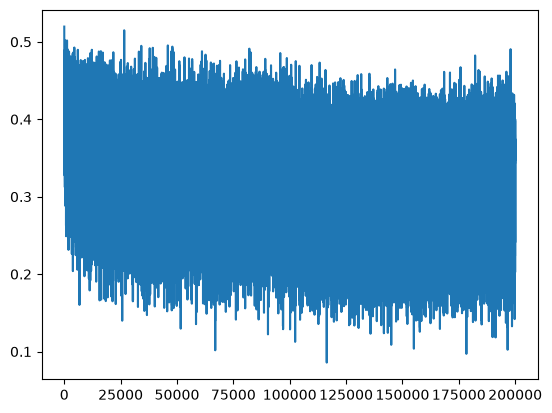

In [19]:
plt.plot(lossi)

In [20]:
@torch.no_grad()    # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concatenate into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1)   # (N, n_hidden)
    logits = h @ W2 + b2    # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0343780517578125
val 2.1024086475372314


In [12]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size  # intialize with all...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])]    # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we same the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))    # decode and print the generated word

carmah.
ambril.
khirmin.
rehtleenanden.
jazhetraymerynco.
geni.
ner.
kiah.
maiir.
kaleigh.
ham.
jore.
quint.
sulin.
alian.
quinterry.
jarynix.
kael.
drudbwed.
emi.


In [ ]:
# 00:27:53 hrs